In [1]:
import pandas as pd
pd.options.display.max_columns = None
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, Perceptron, SGDClassifier, RidgeClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, cross_val_score, train_test_split, HalvingGridSearchCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
from datetime import datetime

### Preprocessing

In [ ]:
1/0

In [2]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])

Based on discoveries of EDA, I delete some featurs and transform others.

In [3]:
df.rename(columns={'trans_date_trans_time':'time', 'amt':'amount'}, inplace=True)
df['day'] = df['time'].dt.day
df['weekday'] = df['time'].dt.weekday
df['hour'] = df['time'].dt.hour
df['industry_code'] = df['cc_num'].astype(str).apply(lambda x: x[0:1]).astype(int)
df['age'] = (pd.to_datetime('today') - pd.to_datetime(df['dob'])).dt.days/365.25 
df.drop(columns=['time', 'first', 'last', 'street', 'trans_num', 'unix_time', 'cc_num', 'dob', 'lat', 'long', 'merch_lat', 'merch_long', 'zip', 'city', 'job', 'merchant'], inplace=True)

### Feature generation

In [4]:
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

str_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include='number').columns

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, dtype=bool), str_cols),
        ('transformer', PolynomialFeatures(degree=3, include_bias=False), num_cols),
    ],
    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

df = preprocessor.fit_transform(df)
df.head()

,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,amount,city_pop,day,weekday,hour,industry_code,age,amount^2,amount city_pop,amount day,amount weekday,amount hour,amount industry_code,amount age,city_pop^2,city_pop day,city_pop weekday,city_pop hour,city_pop industry_code,city_pop age,day^2,day weekday,day hour,day industry_code,day age,weekday^2,weekday hour,weekday industry_code,weekday age,hour^2,hour industry_code,hour age,industry_code^2,industry_code age,age^2,amount^3,amount^2 city_pop,amount^2 day,amount^2 weekday,amount^2 hour,amount^2 industry_code,amount^2 age,amount city_pop^2,amount city_pop day,amount city_pop weekday,amount city_pop hour,amount city_pop industry_code,amount city_pop age,amount day^2,amount day weekday,amount day hour,amount day industry_code,amount day age,amount weekday^2,amount weekday hour,amount weekday industry_code,amount weekday age,amount hour^2,amount hour industry_code,amount hour age,amount industry_code^2,amount industry_code age,amount age^2,city_pop^3,city_pop^2 day,city_pop^2 weekday,city_pop^2 hour,city_pop^2 industry_code,city_pop^2 age,city_pop day^2,city_pop day weekday,city_pop day hour,city_pop day industry_code,city_pop day age,city_pop weekday^2,city_pop weekday hour,city_pop weekday industry_code,city_pop weekday age,city_pop hour^2,city_pop hour industry_code,city_pop hour age,city_pop industry_code^2,city_pop industry_code age,city_pop age^2,day^3,day^2 weekday,day^2 hour,day^2 industry_code,day^2 age,day weekday^2,day weekday hour,day weekday industry_code,day weekday age,day hour^2,day hour industry_code,day hour age,day industry_code^2,day industry_code age,day age^2,weekday^3,weekday^2 hour,weekday^2 industry_code,weekday^2 age,weekday hour^2,weekday hour industry_code,weekday hour age,weekday industry_code^2,weekday industry_code age,weekday age^2,hour^3,hour^2 industry_code,hour^2 age,hour industry_code^2,hour industry_code age,hour age^2,industry_code^3,industry_code^2 age,industry_code age^2,age^3
0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4.97,3495.0,1.0,1.0,0.0,2.0,36.678987,24.7009,17370.15,4.97,4.97,0.0,9.94,182.294565,12215025.0,3495.0,3495.0,0.0,6990.0,128193.059548,1.0,1.0,0.0,2.0,36.678987,1.0,0.0,2.0,36.678987,0.0,0.0,0.0,4.0,73.357974,1345.348087,1.227635e+02,8.632965e+04,24.7009,24.7009,0.0,49.4018,9.060040e+02,6.070867e+07,17370.15,17370.15,0.0,34740.30,6.371195e+05,4.97,4.97,0.0,9.94,182.294565,4.97,0.0,9.94,182.294565,0.0,0.0,0.0,19.88,364.589131,6686.379992,4.269151e+10,12215025.0,12215025.0,0.0,24430050.0,4.480347e+08,3495.0,3495.0,0.0,6990.0,128193.059548,3495.0,0.0,6990.0,128193.059548,0.0,0.0,0.0,13980.0,256386.119097,4.701992e+06,1.0,1.0,0.0,2.0,36.678987,1.0,0.0,2.0,36.678987,0.0,0.0,0.0,4.0,73.357974,1345.348087,1.0,0.0,2.0,36.678987,0.0,0.0,0.0,4.0,73.357974,1345.348087,0.0,0.0,0.0,0.0,0.0,0.0,8.0,146.715948,2690.696174,49346.004987
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

In [6]:
def evaluate(title):
    models = dict()
    
    models['Logistic Regression'] = LogisticRegression(random_state=1, max_iter=100000, class_weight='balanced')    
    #models['SVC'] = SVC(class_weight='balanced', random_state=1)#took more than 19h, interrupted    
    models['SGD'] = SGDClassifier(random_state=1, class_weight='balanced')
    models['Nearest Neighbor'] = KNeighborsClassifier(3)
    models['Naive Bayes'] = GaussianNB()
    models['Decision Tree'] = DecisionTreeClassifier(random_state=1, class_weight='balanced')
    models['Random Forest'] = RandomForestClassifier(random_state=1, class_weight='balanced')
    models['MLPC'] = MLPClassifier(random_state=1)
    
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=1)
    
    res = pd.DataFrame()
    test_res = pd.DataFrame()
    
    for name, model in models.items():
        print(name, datetime.now())
        gs = GridSearchCV(model, cv=cv, n_jobs=10, param_grid={}, scoring='f1_weighted')
        gs.fit(X_train, y_train)
        test_res[name] = [f1_score(y_test, gs.predict(X_test), average='weighted')]

        scores = []
        for i in range(cv.get_n_splits()):
            scores.append(gs.cv_results_['split' + str(i) + '_test_score'][0])

        res[name] = scores
    
    print(datetime.now())

    plt.figure(figsize=(7, 6))
    sns.boxplot(data=res).set_title(title)

    for i in range(res.shape[1]):    
        y_delta = (res.iloc[:, i].max() - res.iloc[:, i].min()) *  0.01
        plt.text(i - 0.4, res.iloc[:, i].max() + y_delta, 'Test: ' + str(test_res.iloc[0, i])[:6], fontsize=8)
        plt.text(i - 0.4, res.iloc[:, i].min() - y_delta*4.5, 'Train mean: \n' + str(res.iloc[:, i].mean())[:6], fontsize=8)
        
    plt.xticks(rotation=20) 
    #plt.grid()

### Feature selection

In [6]:
scaler = ColumnTransformer(
    transformers=[('scaler', StandardScaler(), df.select_dtypes(include='number').columns)],
                    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
        
df = scaler.fit_transform(df)
df.head()

,amount,city_pop,day,weekday,hour,industry_code,age,amount^2,amount city_pop,amount day,amount weekday,amount hour,amount industry_code,amount age,city_pop^2,city_pop day,city_pop weekday,city_pop hour,city_pop industry_code,city_pop age,day^2,day weekday,day hour,day industry_code,day age,weekday^2,weekday hour,weekday industry_code,weekday age,hour^2,hour industry_code,hour age,industry_code^2,industry_code age,age^2,amount^3,amount^2 city_pop,amount^2 day,amount^2 weekday,amount^2 hour,amount^2 industry_code,amount^2 age,amount city_pop^2,amount city_pop day,amount city_pop weekday,amount city_pop hour,amount city_pop industry_code,amount city_pop age,amount day^2,amount day weekday,amount day hour,amount day industry_code,amount day age,amount weekday^2,amount weekday hour,amount weekday industry_code,amount weekday age,amount hour^2,amount hour industry_code,amount hour age,amount industry_code^2,amount industry_code age,amount age^2,city_pop^3,city_pop^2 day,city_pop^2 weekday,city_pop^2 hour,city_pop^2 industry_code,city_pop^2 age,city_pop day^2,city_pop day weekday,city_pop day hour,city_pop day industry_code,city_pop day age,city_pop weekday^2,city_pop weekday hour,city_pop weekday industry_code,city_pop weekday age,city_pop hour^2,city_pop hour industry_code,city_pop hour age,city_pop industry_code^2,city_pop industry_code age,city_pop age^2,day^3,day^2 weekday,day^2 hour,day^2 industry_code,day^2 age,day weekday^2,day weekday hour,day weekday industry_code,day weekday age,day hour^2,day hour industry_code,day hour age,day industry_code^2,day industry_code age,day age^2,weekday^3,weekday^2 hour,weekday^2 industry_code,weekday^2 age,weekday hour^2,weekday hour industry_code,weekday hour age,weekday industry_code^2,weekday industry_code age,weekday age^2,hour^3,hour^2 industry_code,hour^2 age,hour industry_code^2,hour industry_code age,hour age^2,industry_code^3,industry_code^2 age,industry_code age^2,age^3,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,-0.407826,-0.282589,-1.652258,-0.941975,-1.878145,-1.351318,-0.829704,-0.017526,-0.112019,-0.378775,-0.333685,-0.31736,-0.374022,-0.377993,-0.159244,-0.252566,-0.231344,-0.25615,-0.265850,-0.290929,-1.117074,-0.983951,-1.199037,-1.411667,-1.386110,-0.975053,-1.031079,-0.996509,-0.923455,-1.260277,-1.532935,-1.583952,-1.113596,-1.239414,-0.786098,-0.004363,-0.007477,-0.016630,-0.012433,-0.015165,-0.014130,-0.014366,-0.068348,-0.096193,-0.088585,-0.086016,-0.115129,-0.118048,-0.318495,-0.301759,-0.275915,-0.338344,-0.354696,-0.300560,-0.249979,-0.297901,-0.300018,-0.267061,-0.286423,-0.289758,-0.316070,-0.342202,-0.317798,-0.11199,-0.138177,-0.128560,-0.140669,-0.140257,-0.166542,-0.215083,-0.202398,-0.221022,-0.233914,-0.257874,-0.206945,-0.204331,-0.216723,-0.237900,-0.227251,-0.23837,-0.264297,-0.235479,-0.262942,-0.277938,-0.877768,-0.765916,-0.87468,-1.000771,-0.995811,-0.810183,-0.802451,-0.899492,-0.891542,-0.930955,-1.063967,-1.08611,-1.044968,-1.222184,-1.000601,-0.872922,-0.830376,-0.909062,-0.892334,-0.826553,-0.931348,-0.948793,-0.847919,-0.932963,-0.765823,-1.003556,-1.111474,-1.123682,-1.096646,-1.343843,-1.098038,-0.893107,-1.060522,-0.944895,-0.701923,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

In [7]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1)
del df

In [20]:
X_train_bkp = X_train.copy()
X_test_bkp = X_test.copy()
y_train_bkp = y_train.copy()
y_test_bkp = y_test.copy()

In [ ]:
import prince

famd = prince.FAMD(n_components=20, random_state=42)
famd.fit(X_train)

C:\Users\dfskl\anaconda3\envs\python3_10_14\lib\site-packages\prince\pca.py:178: PerformanceWarning: Concatenating sparse arrays with multiple fill values: '[-5.45376882384957, -1.5021336877942928, -5.361853984613893, -1.8029203664277902, -5.557015225685405, -1.0581029163085116, -5.380572335708566, -1.746264968499245, -5.466222592598931, -1.4561629607159425, -5.3814987483254715, -1.7434079332650125, -5.404631807679989, -1.6703158454058133, -5.51770986818603, -1.2469473968546172, -5.480665691822787, -1.4008224635822561, -5.455252834397045, -1.4967352848125837, -5.439656580421517, -1.552461364117282, -5.39608629893163, -1.6977198398093656, -5.567893824090919, -0.9992789218482487, -4.186110324541877, -3.804797018339336, -5.566587623240267, -1.0065297972679603, -5.588804507837312, -0.8747937889453363, -5.633048425415606, -0.5184259223097879, -5.532437866187587, -1.1798861202564157, -5.626209879556291, -0.5880156385532536, -5.640129548151369, -0.4346707720445903, -5.649028174116599, -0.2974

In [ ]:
X_train = famd.transform(X_train)
X_test = famd.transform(X_test)

In [10]:
X_train.head()

component,0,1
167764,-3.236458,15.295393
860668,6.333896,-6.572632
36004,2.326845,0.124054
964106,2.855459,5.699725
1017829,-12.723967,-12.046769


In [14]:
X_test.head()

component,0,1
94102,-6.708567,9.704942
198791,4.433698,5.231018
1238587,3.534257,-0.174804
619078,7.624227,3.620869
573850,-3.562643,-7.883671


In [ ]:
selector = ColumnTransformer(
    transformers=[('pca', PCA(n_components=0.99, copy=False, random_state=1), X_train.select_dtypes(include='number').columns)],
                    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

print('Features before reduction:', X_train.shape[1])
X_train = selector.fit_transform(X_train)
X_test = selector.transform(X_test)
print('Features after reduction:', X_train.shape[1])

In [ ]:
MCA
import prince 

mca = prince.MCA(n_components=2, random_state=42)
mca_result = mca.fit(data)

# obtain inertia to plot
exp_inertia = mca_result.explained_inertia_


t-SNE, UMAP

### Handling imbalanced data

In [13]:
#NearMiss
from imblearn.under_sampling import NearMiss
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = NearMiss(n_jobs=5).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(972506, 104) 966781 5725
(11450, 104) 5725 5725


In [ ]:
#TomekLinks-----------------------------------------------------------------------------------------------------------------------------
from imblearn.under_sampling import TomekLinks
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = TomekLinks(n_jobs=5).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

In [ ]:
#ClusterCentroids
from imblearn.under_sampling import ClusterCentroids
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = ClusterCentroids().fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(972506, 104) 966781 5725


C:\Users\irama\.conda\envs\Python_10\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [12]:
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(11450, 104) 5725 5725


In [ ]:
#EditedNearestNeighbours
from imblearn.under_sampling import EditedNearestNeighbours
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = EditedNearestNeighbours(n_jobs=5).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

In [ ]:
#Oversampler
from imblearn.over_sampling import RandomOverSampler
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = RandomOverSampler(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

In [10]:
#SMOTE
from imblearn.over_sampling import SMOTE
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = SMOTE(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(972506, 104) 966781 5725
(1933562, 104) 966781 966781


In [ ]:
#BSMOTE
from imblearn.over_sampling import BorderlineSMOTE
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = SMOTE(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

In [ ]:
#ADASYN
from imblearn.over_sampling import ADASYN
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = ADASYN(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

In [ ]:
#SMOTEENN
from imblearn.over_sampling import SMOTEENN
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = SMOTEENN(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

In [ ]:
#SMOTETomek
from imblearn.over_sampling import SMOTETomek
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = SMOTETomek(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

In [ ]:
1/0

Logistic Regression 2024-11-10 13:39:17.793103
SGD 2024-11-10 13:40:01.189437
Nearest Neighbor 2024-11-10 13:40:55.930871
Naive Bayes 2024-11-10 14:10:28.679342
Decision Tree 2024-11-10 14:10:38.050016
Random Forest 2024-11-10 14:11:06.417616
MLPC 2024-11-10 14:18:22.361319


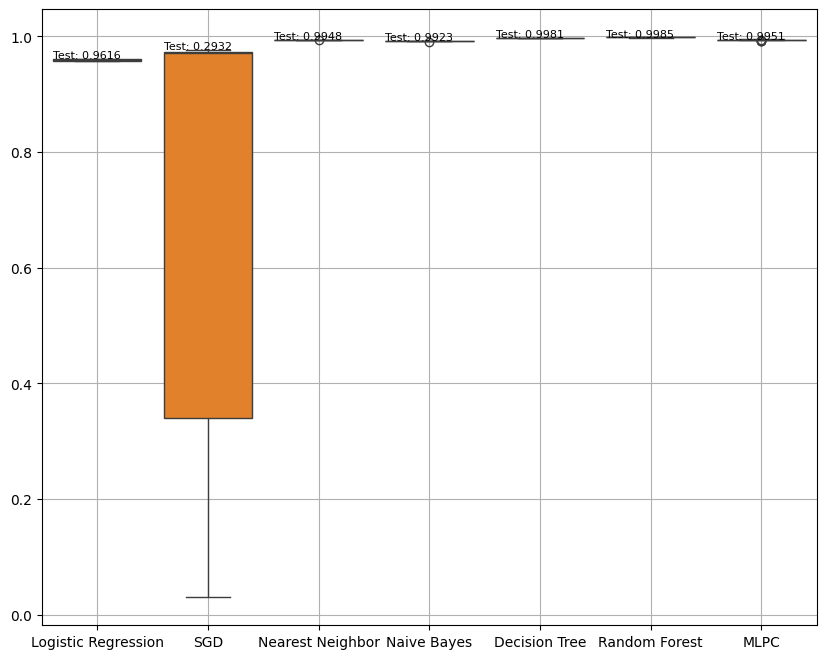

In [12]:
#one hot
#no Scaler, PF, PCA and SMOTE
evaluate()

Logistic Regression 2024-11-10 16:00:02.186298
SGD 2024-11-10 16:04:31.041622
Nearest Neighbor 2024-11-10 16:05:18.415136
Naive Bayes 2024-11-10 16:34:31.124479
Decision Tree 2024-11-10 16:34:41.407526
Random Forest 2024-11-10 16:35:09.341733
MLPC 2024-11-10 16:42:16.059323
2024-11-10 16:51:08.339100


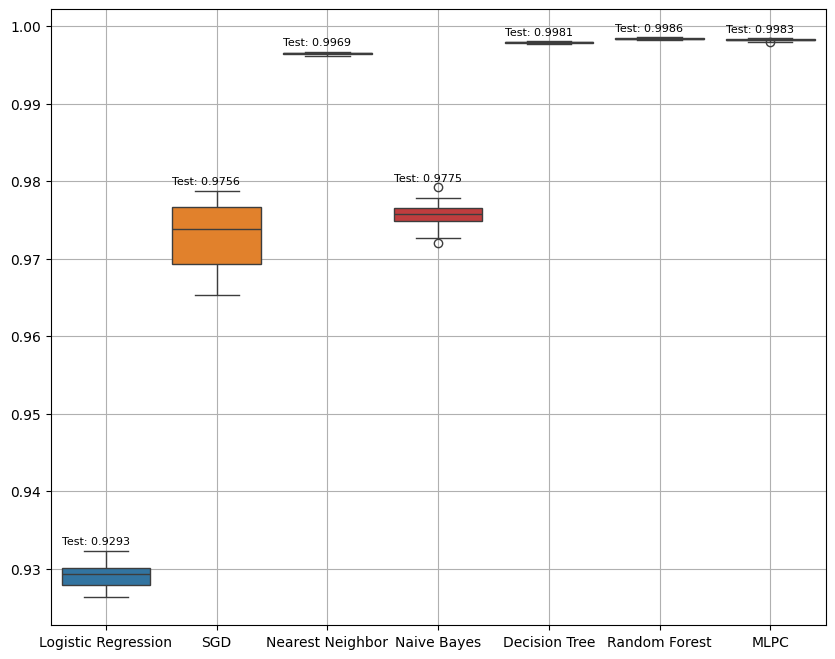

In [9]:
#one hot, Scaler
#no PF, PCA and SMOTE
evaluate()

Logistic Regression 2024-11-10 17:42:32.752014
SGD 2024-11-10 18:36:05.867762
Nearest Neighbor 2024-11-10 18:39:30.905697
Naive Bayes 2024-11-10 19:37:45.144277
Decision Tree 2024-11-10 19:39:55.308276
Random Forest 2024-11-10 19:45:00.133953
MLPC 2024-11-10 20:16:03.626139
2024-11-10 21:17:38.828184


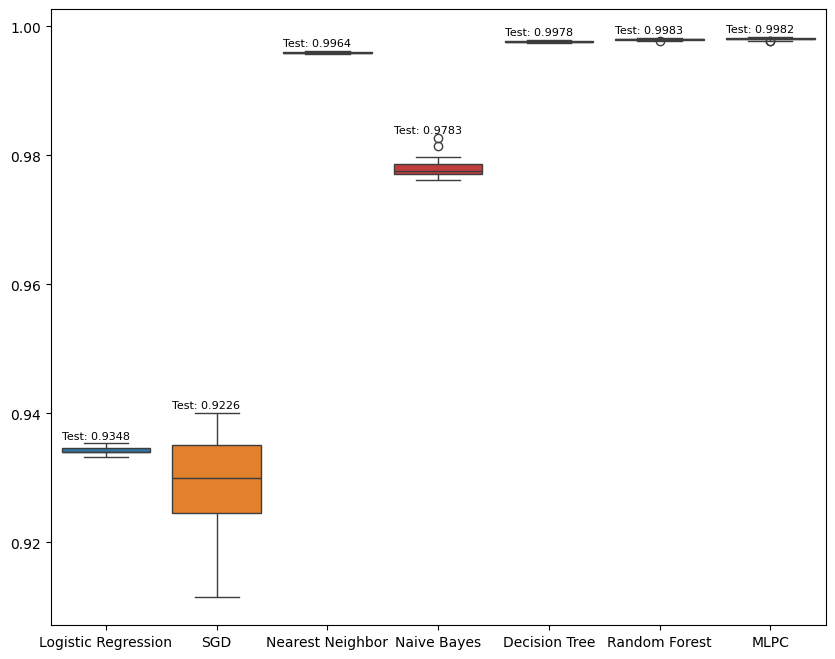

In [10]:
#one hot, Scaler, PF
#no PCA, SMOTE
evaluate()

Logistic Regression 2024-11-10 21:21:39.852466
SGD 2024-11-10 21:36:02.172542
Nearest Neighbor 2024-11-10 21:37:16.055818
Naive Bayes 2024-11-10 22:13:59.290497
Decision Tree 2024-11-10 22:14:13.387767
Random Forest 2024-11-10 22:21:02.289399
MLPC 2024-11-10 23:08:26.620795
2024-11-10 23:38:48.569257


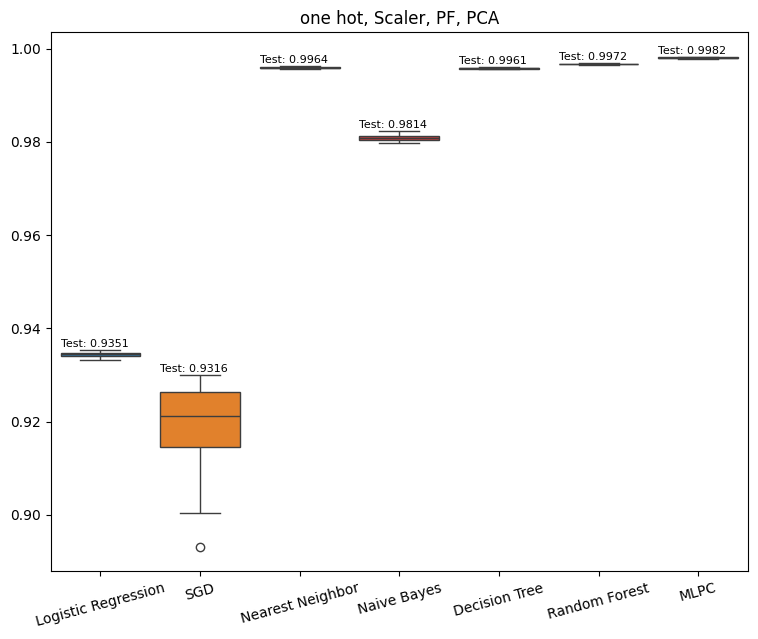

In [11]:
#one hot, Scaler, PF, PCA
#no SMOTE
evaluate('one hot, Scaler, PF, PCA')

Logistic Regression 2024-11-11 11:18:35.544698
SGD 2024-11-11 11:46:58.756241
Nearest Neighbor 2024-11-11 11:47:43.009213
Naive Bayes 2024-11-11 14:09:07.072472
Decision Tree 2024-11-11 14:10:18.044120
Random Forest 2024-11-11 14:32:46.839294
MLPC 2024-11-11 16:37:51.240239
2024-11-11 17:36:34.144749


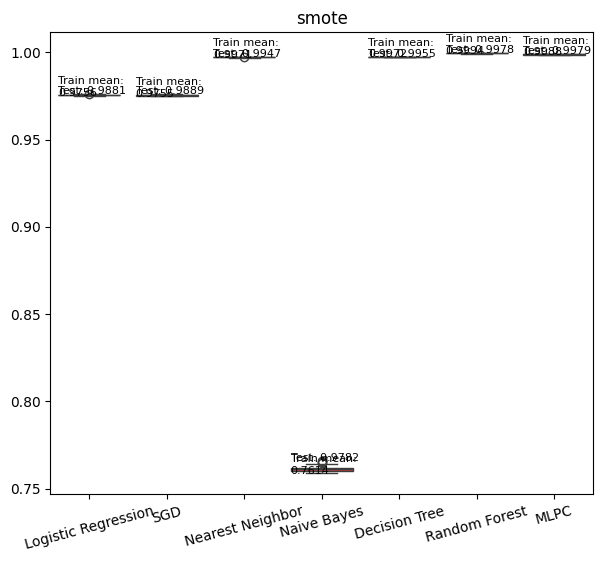

In [11]:
# one hot, Scaler,PF, PCA and SMOTE
evaluate('smote')

Logistic Regression 2024-11-11 17:46:00.013794
SGD 2024-11-11 17:46:03.622942
Nearest Neighbor 2024-11-11 17:46:04.458241
Naive Bayes 2024-11-11 17:46:12.518332
Decision Tree 2024-11-11 17:46:13.431851
Random Forest 2024-11-11 17:46:15.602058
MLPC 2024-11-11 17:46:30.398723


C:\Users\irama\.conda\envs\Python_10\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


2024-11-11 17:47:09.780607


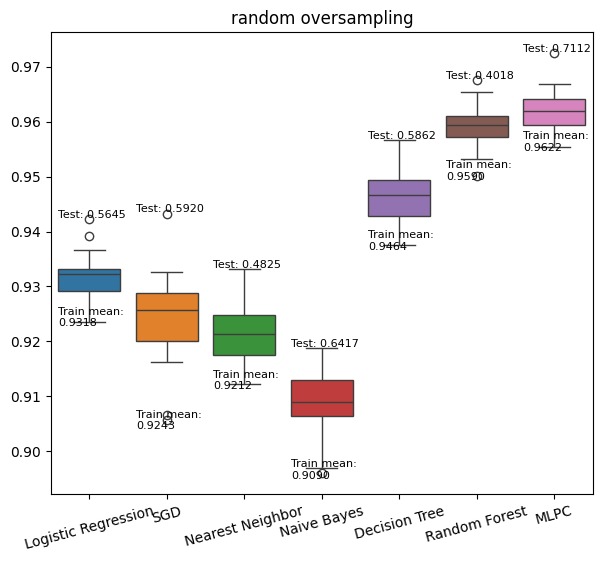

In [14]:
# one hot, Scaler,PF, PCA and NearMiss
evaluate('random oversampling')

In [ ]:
# one hot, Scaler,PF, PCA and TomekLinks-----------------
evaluate('TomekLinks')

Logistic Regression 2024-11-11 21:20:36.358016
SGD 2024-11-11 21:20:45.449114
Nearest Neighbor 2024-11-11 21:20:46.047316
Naive Bayes 2024-11-11 21:20:54.028122
Decision Tree 2024-11-11 21:20:54.918098
Random Forest 2024-11-11 21:20:56.575140
MLPC 2024-11-11 21:21:08.471931
2024-11-11 21:21:23.096280


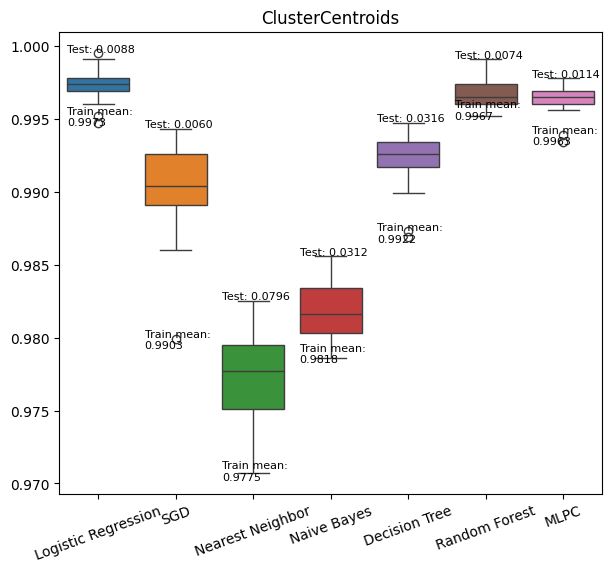

In [13]:
# one hot, Scaler,PF, PCA and ClusterCentroids
evaluate('ClusterCentroids')

In [ ]:
# one hot, Scaler,PF, PCA and 
evaluate('')

In [ ]:
# one hot, Scaler,PF, PCA and 
evaluate('')

In [ ]:
# one hot, Scaler,PF, PCA and 
evaluate('')

In [ ]:
# one hot, Scaler,PF, PCA and 
evaluate('')

In [ ]:
# one hot, Scaler,PF, PCA and 
evaluate('')

In [ ]:
# one hot, Scaler,PF, PCA and 
evaluate('')

In [ ]:
# one hot, Scaler,PF, PCA and 
evaluate('')